In [40]:
study_name = "arch_simple_alphanumeric_16"
results_path = f"results/{study_name}"
problem_type = "classification"

In [41]:
""" Imports """
%load_ext autoreload
%autoreload 2

import os
import matplotlib.pyplot as plt

import torch
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from latent_model.temporal_prediction import create_models_list, create_loaders

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
"""Utility Functions"""
def plot_regression_results(y_true, y_pred, label_type):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--', label="Ideal Fit")
    plt.title(f"Parity Plot for {label_type}")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

def plot_classification_results(y_true, y_pred, label_type, class_names):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, colorbar=False)
    plt.title(label_type, fontsize=24)
    plt.show()

In [43]:
loaders = create_loaders(results_path, seq_len=9)
temporal_models = {}
for model_name in os.listdir(results_path):
    temporal_models[model_name] = {}
    model_path = f"{results_path}/{model_name}/_best_model"
    for dataset_name in os.listdir(model_path):
        loader = loaders[model_name][dataset_name]
        num_dims = loader.num_dims
        temporal_models[model_name][dataset_name] = create_models_list(
            input_size=num_dims, output_size=12, classification=True
        )

label_encoder = LabelEncoder()
label_encoder.fit([arr.split("_")[0] for dataset in loaders.values() for loader in dataset.values() for _, sample_id in loader.get_dataloader("train") for arr in sample_id])

def transform_sample_id(sample_id):
    labels = [arr.split("_")[0] for arr in sample_id]
    indices = torch.tensor(label_encoder.transform(labels), dtype=torch.long)
    return torch.nn.functional.one_hot(indices, num_classes=len(label_encoder.classes_)).float()


In [44]:
best_models = {}
patience = 5 
max_epochs = 50
    
for model_name, dataset in loaders.items():
    best_models[model_name] = {}
    for dataset_name, loader in dataset.items():
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")

        for model in temporal_models[model_name][dataset_name]:
            best_model = None
            best_loss = float("inf")
            no_improvement_count = 0
            # Train
            model.train()
            for epoch in range(max_epochs):
                epoch_loss = 0.0
                for embeddings, sample_id in train_loader:
                    x_batch = embeddings
                    y_batch = transform_sample_id(sample_id)
                    model.optimizer.zero_grad()
                    y_pred = model(x_batch)
                    loss = model.criterion(y_pred, y_batch)
                    loss.backward()
                    model.optimizer.step()
                    epoch_loss += loss.item()
                epoch_loss /= len(train_loader)
                # Eval
                model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for embeddings, sample_id in val_loader:
                        x_batch = embeddings
                        y_batch = transform_sample_id(sample_id)
                        y_pred = model(x_batch)
                        val_loss += model.criterion(y_pred, y_batch).item()

                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    best_model = model
                    no_improvement_count = 0
                else:
                    no_improvement_count += 1

                if no_improvement_count >= patience:
                    break

            best_models[model_name][dataset_name] = best_model
print("Training complete")
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")
print(f"Testing samples: {len(test_loader.dataset)}")

Training complete
Training samples: 230
Validation samples: 58
Testing samples: 72


              precision    recall  f1-score   support

           2       0.31      0.83      0.45         6
           a       0.67      0.22      0.33         9
           b       0.50      0.50      0.50         8
           d       0.44      0.57      0.50         7
           e       0.50      0.33      0.40         6
           i       0.00      0.00      0.00         1
           j       0.00      0.00      0.00         6
           k       0.67      0.29      0.40         7
           p       0.20      0.50      0.29         2
           u       1.00      0.50      0.67         6
           x       0.11      0.20      0.14         5
           z       0.00      0.00      0.00         9

    accuracy                           0.33        72
   macro avg       0.37      0.33      0.31        72
weighted avg       0.41      0.33      0.33        72



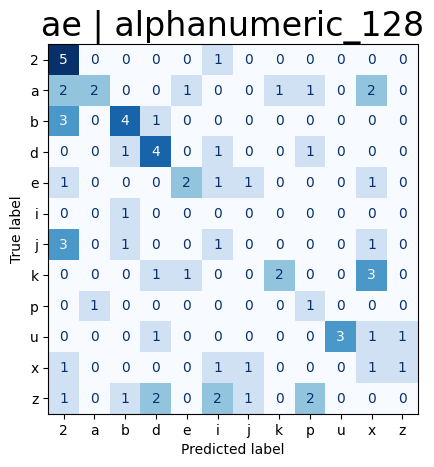

              precision    recall  f1-score   support

           2       0.80      0.67      0.73         6
           a       0.67      0.22      0.33         9
           b       0.00      0.00      0.00         8
           d       0.33      0.57      0.42         7
           e       0.22      0.33      0.27         6
           i       0.00      0.00      0.00         1
           j       1.00      0.17      0.29         6
           k       0.50      0.43      0.46         7
           p       0.17      0.50      0.25         2
           u       0.38      0.50      0.43         6
           x       0.14      0.20      0.17         5
           z       0.29      0.22      0.25         9

    accuracy                           0.32        72
   macro avg       0.37      0.32      0.30        72
weighted avg       0.41      0.32      0.32        72



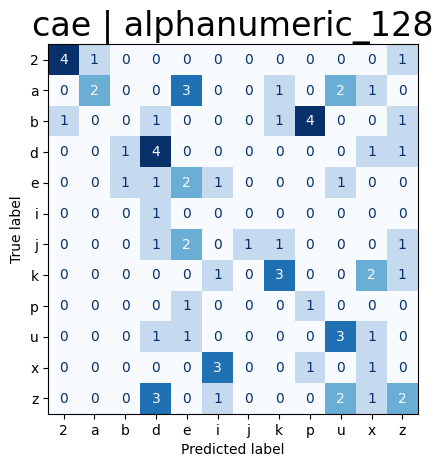

              precision    recall  f1-score   support

           2       0.75      0.50      0.60         6
           a       1.00      0.22      0.36         9
           b       0.80      0.50      0.62         8
           d       1.00      0.57      0.73         7
           e       0.33      0.33      0.33         6
           i       0.12      1.00      0.22         1
           j       0.14      0.17      0.15         6
           k       0.57      0.57      0.57         7
           p       0.33      0.50      0.40         2
           u       0.43      0.50      0.46         6
           x       0.40      0.40      0.40         5
           z       0.29      0.44      0.35         9

    accuracy                           0.43        72
   macro avg       0.51      0.48      0.43        72
weighted avg       0.58      0.43      0.45        72



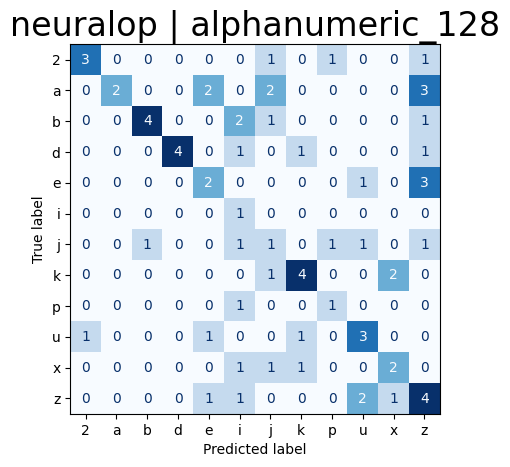

In [45]:
# Build inverse mapping dynamically from LabelEncoder
inverse_mapping = {i: class_name for i, class_name in enumerate(label_encoder.classes_)}

for model_name, dataset in best_models.items():
    for dataset_name, model in dataset.items():
        y_true_labels = []
        y_pred_labels = []

        test_loader = loaders[model_name][dataset_name].get_dataloader("test")  # Get test loader

        # Test
        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in test_loader:
                x_batch = embeddings
                y_batch = transform_sample_id(sample_id).to(torch.float)  # One-hot encoded labels

                y_pred = model(x_batch)

                # Convert one-hot to class indices
                y_true_labels.extend(y_batch.argmax(dim=1).cpu().numpy())  
                y_pred_labels.extend(y_pred.argmax(dim=1).cpu().numpy())  

        # Convert class indices back to original string labels
        class_names = list(inverse_mapping.values())  
        y_test_original = [inverse_mapping[label] for label in y_true_labels]
        y_pred_original = [inverse_mapping[label] for label in y_pred_labels]

        print(classification_report(y_test_original, y_pred_original, zero_division=0))
        plot_classification_results(y_true_labels, y_pred_labels, f"{model_name} | {dataset_name}", class_names)